In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
with open("../data/Ames_Housing_Feature_Description.txt", "r") as file:
    print(file.read())


MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

In [2]:
df=pd.read_csv("../data/Ames_NO_Missing_Data.csv")

In [3]:
df

,Unnamed: 0.1,Unnamed: 0,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,0,0,20,RL,141.000000,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,1,1,20,RH,80.000000,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,2,2,20,RL,81.000000,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,3,3,20,RL,93.000000,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,4,4,60,RL,74.000000,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,2922,2925,80,RL,37.000000,7937,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2006,WD,Normal,142500
2921,2923,2926,20,RL,75.144444,8885,Pave,IR1,Low,AllPub,...,0,0,0,0,0,6,2006,WD,Normal,131000
2922,2924,2927,85,RL,62.000000,10441,Pave,Reg,Lvl,AllPub,...,0,0,0,0,700,7,2006,WD,Normal,132000
2923,2925,2928,20,RL,77.000000,10010,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2006,WD,Normal,170000


In [4]:
df['MS SubClass']=df['MS SubClass'].apply(str)

In [5]:
direction=pd.Series(['Up','Up','Down'])

In [18]:
direction

0      Up
1      Up
2    Down
dtype: object

In [20]:
pd.get_dummies(direction,dtype=int)

,Down,Up
0,0,1
1,0,1
2,1,0


In [6]:
df.select_dtypes(include="object")

,MS SubClass,MS Zoning,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,...,Kitchen Qual,Functional,Fireplace Qu,Garage Type,Garage Finish,Garage Qual,Garage Cond,Paved Drive,Sale Type,Sale Condition
0,20,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,TA,Typ,Gd,Attchd,Fin,TA,TA,P,WD,Normal
1,20,RH,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,...,TA,Typ,NaN,Attchd,Unf,TA,TA,Y,WD,Normal
2,20,RL,Pave,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Gd,Typ,NaN,Attchd,Unf,TA,TA,Y,WD,Normal
3,20,RL,Pave,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,...,Ex,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal
4,60,RL,Pave,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,TA,Typ,TA,Attchd,Fin,TA,TA,Y,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,80,RL,Pave,IR1,Lvl,AllPub,CulDSac,Gtl,Mitchel,Norm,...,TA,Typ,NaN,Detchd,Unf,TA,TA,Y,WD,Normal
2921,20,RL,Pave,IR1,Low,AllPub,Inside,Mod,Mitchel,Norm,...,TA,Typ,NaN,Attchd,Unf,TA,TA,Y,WD,Normal
2922,85,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,...,TA,Typ,NaN,NaN,NaN,NaN,NaN,Y,WD,Normal
2923,20,RL,Pave,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,...,TA,Typ,TA,Attchd,RFn,TA,TA,Y,WD,Normal


In [27]:
df.info();

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2925 entries, 0 to 2924
Data columns (total 78 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0.1     2925 non-null   int64  
 1   Unnamed: 0       2925 non-null   int64  
 2   MS SubClass      2925 non-null   object 
 3   MS Zoning        2925 non-null   object 
 4   Lot Frontage     2925 non-null   float64
 5   Lot Area         2925 non-null   int64  
 6   Street           2925 non-null   object 
 7   Lot Shape        2925 non-null   object 
 8   Land Contour     2925 non-null   object 
 9   Utilities        2925 non-null   object 
 10  Lot Config       2925 non-null   object 
 11  Land Slope       2925 non-null   object 
 12  Neighborhood     2925 non-null   object 
 13  Condition 1      2925 non-null   object 
 14  Condition 2      2925 non-null   object 
 15  Bldg Type        2925 non-null   object 
 16  House Style      2925 non-null   object 
 17  Overall Qual  

In [28]:
my_object_df=df.select_dtypes(include='object')

In [29]:
my_numeric_df=df.select_dtypes(exclude='object')

In [32]:
df_objects_dummies=pd.get_dummies(my_object_df,dtype=int)
df_objects_dummies

,MS SubClass_120,MS SubClass_150,MS SubClass_160,MS SubClass_180,MS SubClass_190,MS SubClass_20,MS SubClass_30,MS SubClass_40,MS SubClass_45,MS SubClass_50,...,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
3,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2921,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2922,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0
2923,0,0,0,0,0,1,0,0,0,0,...,0,0,0,1,0,0,0,0,1,0


In [33]:
final_df=pd.concat([my_numeric_df,df_objects_dummies],axis=1)

In [34]:
final_df

,Unnamed: 0.1,Unnamed: 0,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,...,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,0,0,141.000000,31770,6,5,1960,1960,112.0,639.0,...,0,0,0,1,0,0,0,0,1,0
1,1,1,80.000000,11622,5,6,1961,1961,0.0,468.0,...,0,0,0,1,0,0,0,0,1,0
2,2,2,81.000000,14267,6,6,1958,1958,108.0,923.0,...,0,0,0,1,0,0,0,0,1,0
3,3,3,93.000000,11160,7,5,1968,1968,0.0,1065.0,...,0,0,0,1,0,0,0,0,1,0
4,4,4,74.000000,13830,5,5,1997,1998,0.0,791.0,...,0,0,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2920,2922,2925,37.000000,7937,6,6,1984,1984,0.0,819.0,...,0,0,0,1,0,0,0,0,1,0
2921,2923,2926,75.144444,8885,5,5,1983,1983,0.0,301.0,...,0,0,0,1,0,0,0,0,1,0
2922,2924,2927,62.000000,10441,5,5,1992,1992,0.0,337.0,...,0,0,0,1,0,0,0,0,1,0
2923,2925,2928,77.000000,10010,5,5,1974,1975,0.0,1071.0,...,0,0,0,1,0,0,0,0,1,0


In [57]:
 data=final_df.corr()['SalePrice'].sort_values().tail(20)

In [58]:
data.index

Index(['BsmtFin SF 1', 'Heating QC_Ex', 'BsmtFin Type 1_GLQ', 'Fireplaces',
       'Exter Qual_Ex', 'TotRms AbvGrd', 'Mas Vnr Area', 'Foundation_PConc',
       'Year Remod/Add', 'Kitchen Qual_Ex', 'Full Bath', 'Year Built',
       'Bsmt Qual_Ex', 'Garage Area', '1st Flr SF', 'Garage Cars',
       'Total Bsmt SF', 'Gr Liv Area', 'Overall Qual', 'SalePrice'],
      dtype='object')

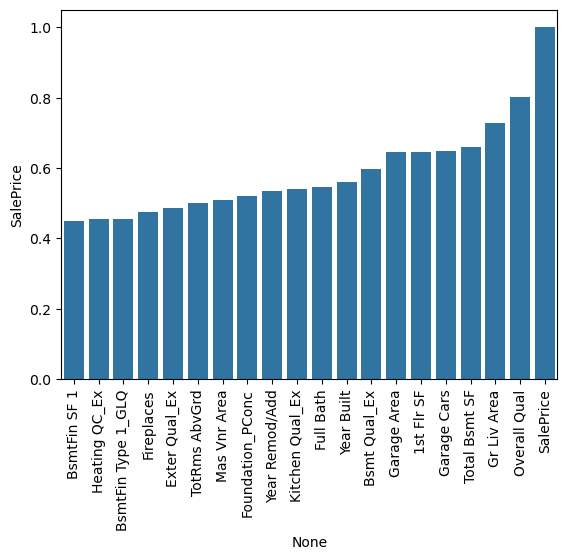

In [60]:
sns.barplot(x=data.index,y=data)
plt.xticks(rotation=90);


In [19]:
final_df.to_csv('../data/AMES_Final_DF.csv')

In [ ]:
df.select_dtypes(include='int')